In [1]:
import subprocess
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

WORKDIR = Path("nh3_ice_vdos")
WORKDIR.mkdir(exist_ok=True)
os.chdir(WORKDIR)

result = subprocess.run(["gmx", "--version"], capture_output=True, text=True)
print(result.stdout[:500])
if result.returncode == 0:
    print("GROMACS is available.")
else:
    print("GROMACS not found.")

                     :-) GROMACS - gmx, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/Ammonia/GROMACS/nh3_ice_vdos
Command line:
  gmx --version

GROMACS version:     2025.4-Homebrew
Precision:           mixed
Memory model:        64 bit
MPI library:         thread_mpi
OpenMP support:      enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:         disabled
S
GROMACS is available.


In [2]:
src_dir = Path("..")

for fname in ["ammonia.gro", "topol.top"]:
    src = src_dir / fname
    dst = Path(fname)
    if dst.exists():
        print(f"{fname} already present in working directory.")
    elif src.exists():
        shutil.copy2(src, dst)
        print(f"Copied {fname} from {src}")
    else:
        print(f"{fname} not found at {src.resolve()}. Please copy it manually into {Path('.').resolve()}")

print(f"\nWorking directory: {Path('.').resolve()}")
print("Contents:")
for f in sorted(Path(".").iterdir()):
    print(f"  {f.name}")

Copied ammonia.gro from ../ammonia.gro
Copied topol.top from ../topol.top

Working directory: /Users/mackenziehenley/cp2k/Ammonia/GROMACS/nh3_ice_vdos
Contents:
  ammonia.gro
  topol.top


In [3]:
with open("ammonia.gro", "r") as f:
    lines = f.readlines()

print(f"Title: {lines[0].strip()}")
n_atoms = int(lines[1].strip())
print(f"Total atoms: {n_atoms}")
print(f"Total molecules: {n_atoms // 4} (4 atoms per NH3)")
print(f"Box vectors (last line): {lines[-1].strip()}")
print(f"\nFirst 8 atom lines (first 2 molecules):")
for line in lines[2:10]:
    print(line, end="")
print(f"\nLast 8 atom lines:")
for line in lines[-9:-1]:
    print(line, end="")

Title: Single ammonia (NH3) molecule - NIST experimental geometry
Total atoms: 2000
Total molecules: 500 (4 atoms per NH3)
Box vectors (last line): 3.00000   3.00000   3.00000

First 8 atom lines (first 2 molecules):
    1NH3      N    1   1.500   1.500   1.529
    1NH3     H1    2   1.500   1.406   1.490
    1NH3     H2    3   1.581   1.547   1.490
    1NH3     H3    4   1.419   1.547   1.490
    2NH3      N    5   2.696   2.676   1.367
    2NH3     H1    6   2.659   2.613   1.437
    2NH3     H2    7   2.623   2.690   1.299
    2NH3     H3    8   2.710   2.765   1.412

Last 8 atom lines:
  499NH3      N 1993   0.554   1.352   2.338
  499NH3     H1 1994   0.619   1.403   2.279
  499NH3     H2 1995   0.494   1.421   2.380
  499NH3     H3 1996   0.496   1.296   2.276
  500NH3      N 1997   1.324   0.554   2.734
  500NH3     H1 1998   1.397   0.577   2.667
  500NH3     H2 1999   1.328   0.454   2.747
  500NH3     H3 2000   1.351   0.596   2.822


In [4]:
with open("topol.top", "r") as f:
    top_content = f.read()

print(top_content)

; Ammonia (NH3) topology file for GROMACS
; Based on OPLS-AA parameters optimized for liquid ammonia
; References: Rizzo & Jorgensen (1999), J. Am. Chem. Soc. 121, 4827-4836
;            Impey et al. (1983), J. Phys. Chem. 87, 5071-5083

[ defaults ]
; nbfunc        comb-rule       gen-pairs       fudgeLJ fudgeQQ
1               2               yes             0.5     0.8333

[ atomtypes ]
; Simpler parameters
;name      mass   charge  ptype  sigma(nm)   epsilon(kJ/mol)
N_nh3    14.0067  -1.02      A       0.3150      0.8500
H_nh3    1.0079   0.34      A       0.0400      0.0800

[ moleculetype ]
; Name            nrexcl
NH3               3

[ atoms ]
; nr   type  resnr residue  atom  cgnr   charge     mass
1      N_nh3  1     NH3      N     1     -1.02     14.0067
2      H_nh3  1     NH3      H1    1      0.34      1.0079
3      H_nh3  1     NH3      H2    1      0.34      1.0079
4      H_nh3  1     NH3      H3    1      0.34      1.0079

[ bonds ]
; i     j       func    b0(nm)     k

In [5]:
shutil.copy2("ammonia.gro", "nh3_sim.gro")
shutil.copy2("topol.top", "nh3_sim.top")

n_mol = 500

print(f"Using full system: {n_mol} NH3 molecules ({n_mol * 4} atoms)")
print(f"Box: 3.0 x 3.0 x 3.0 nm")

Using full system: 500 NH3 molecules (2000 atoms)
Box: 3.0 x 3.0 x 3.0 nm


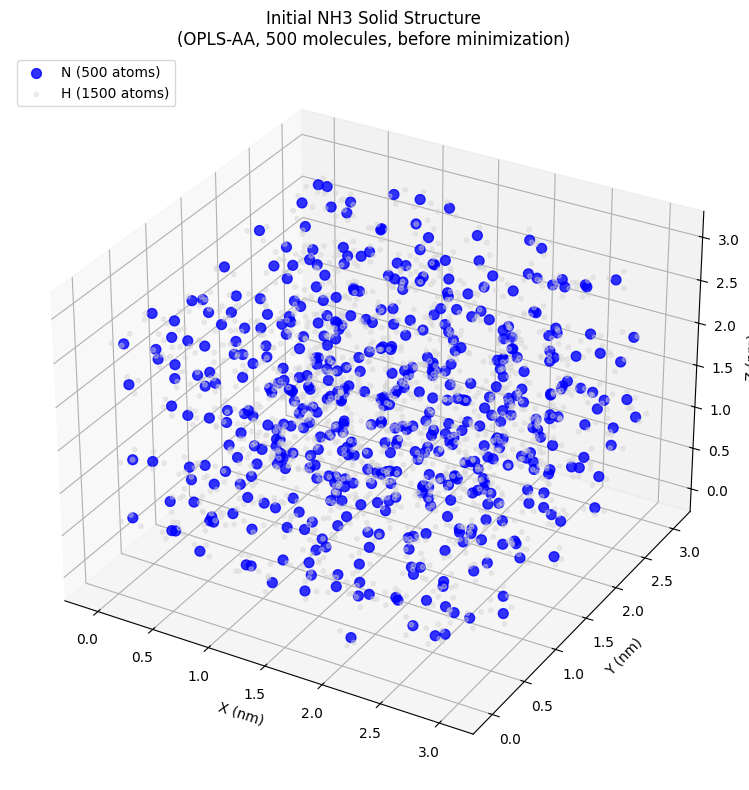

Initial structure visualization saved: initial_structure.png


In [6]:
def parse_gro_positions_nh3(gro_file):
    """Parse atom positions from an NH3 .gro file."""
    with open(gro_file, "r") as f:
        lines = f.readlines()

    n_atoms = int(lines[1].strip())
    positions = {"N": [], "H": []}

    for line in lines[2:2 + n_atoms]:
        atom_name = line[10:15].strip()
        x = float(line[20:28])
        y = float(line[28:36])
        z = float(line[36:44])

        if atom_name == "N":
            positions["N"].append([x, y, z])
        elif atom_name in ("H1", "H2", "H3"):
            positions["H"].append([x, y, z])

    return {k: np.array(v) for k, v in positions.items() if len(v) > 0}


pos = parse_gro_positions_nh3("nh3_sim.gro")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

if "N" in pos:
    n_pos = pos["N"]
    ax.scatter(n_pos[:, 0], n_pos[:, 1], n_pos[:, 2],
               c='blue', s=50, alpha=0.8, label=f'N ({len(n_pos)} atoms)')

if "H" in pos:
    h_pos = pos["H"]
    ax.scatter(h_pos[:, 0], h_pos[:, 1], h_pos[:, 2],
               c='lightgray', s=10, alpha=0.4, label=f'H ({len(h_pos)} atoms)')

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title('Initial NH3 Solid Structure\n(OPLS-AA, 500 molecules, before minimization)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig("initial_structure.png", dpi=150, bbox_inches='tight')
plt.show()
print("Initial structure visualization saved: initial_structure.png")

In [7]:
em_mdp = """\
; Energy minimization for NH3 solid (OPLS-AA)
integrator  = steep
emtol       = 100.0
emstep      = 0.001
nsteps      = 5000

cutoff-scheme = Verlet
nstlist       = 10
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

constraints   = none
"""

with open("em.mdp", "w") as f:
    f.write(em_mdp)
print("Written em.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "em.mdp", "-c", "nh3_sim.gro",
     "-p", "nh3_sim.top", "-o", "em.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print("=== grompp output ===")
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("grompp successful.")

Written em.mdp
=== grompp output ===
g 3 bonded neighbours molecule type 'NH3'
Analysing residue names:
There are:   500      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

The largest distance between excluded atoms is 0.164 nm between atom 1730 and 1732
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 25x25x25, spacing 0.120 0.120 0.120

Estimate for the relative computational load of the PME mesh part: 0.22

This run will generate roughly 0 Mb of data

grompp successful.


In [8]:
result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "em"],
    capture_output=True, text=True
)
print(result.stdout[-1000:] if len(result.stdout) > 1000 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("\nEnergy minimization complete.")



Energy minimization complete.


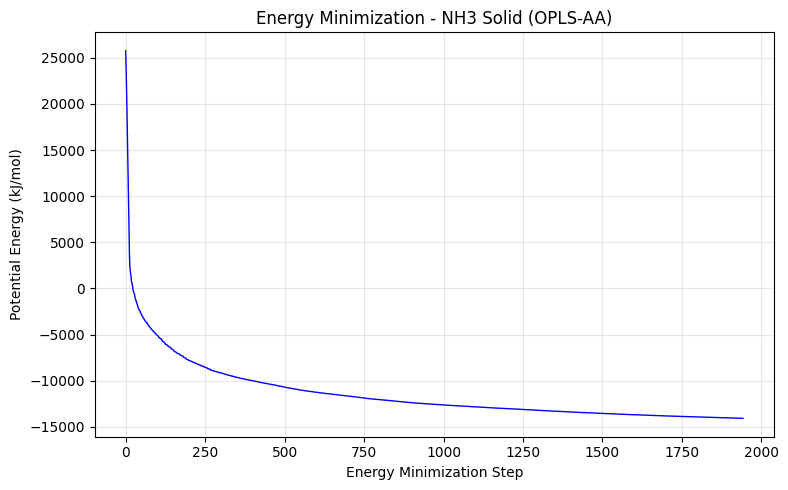

Final potential energy: -14065.6 kJ/mol


In [9]:
def parse_xvg(filename):
    """Parse a GROMACS .xvg file, handling leading whitespace and various formats."""
    x, y = [], []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "@", "&")):
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    x.append(float(parts[0]))
                    y.append(float(parts[1]))
                except ValueError:
                    continue
    return np.array(x), np.array(y)


proc = subprocess.run(
    ["gmx", "energy", "-f", "em.edr", "-o", "em_potential.xvg"],
    input="Potential\n\n", capture_output=True, text=True
)

if os.path.exists("em_potential.xvg"):
    steps, energy = parse_xvg("em_potential.xvg")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(steps, energy, 'b-', linewidth=1)
    ax.set_xlabel("Energy Minimization Step")
    ax.set_ylabel("Potential Energy (kJ/mol)")
    ax.set_title("Energy Minimization - NH3 Solid (OPLS-AA)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("em_energy.png", dpi=150)
    plt.show()
    print(f"Final potential energy: {energy[-1]:.1f} kJ/mol")

In [10]:
nvt_mdp = """\
; NVT equilibration for NH3 solid at 94 K (OPLS-AA)
integrator  = md
dt          = 0.0005
nsteps      = 40000

nstxout     = 1000
nstvout     = 1000
nstenergy   = 100
nstlog      = 1000

cutoff-scheme = Verlet
nstlist       = 20
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

tcoupl        = v-rescale
tc-grps       = System
tau-t         = 0.1
ref-t         = 94

pcoupl        = no

constraints   = none

gen-vel       = yes
gen-temp      = 94
gen-seed      = -1
"""

with open("nvt.mdp", "w") as f:
    f.write(nvt_mdp)
print("Written nvt.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "nvt.mdp", "-c", "em.gro",
     "-p", "nh3_sim.top", "-o", "nvt.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print(result.stdout[-300:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("NVT grompp successful.")

result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "nvt"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr[-300:])
else:
    print("\nNVT equilibration complete.")

Written nvt.mdp

Note that mdrun will redetermine rlist based on the actual pair-list setup
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 25x25x25, spacing 0.120 0.120 0.120

Estimate for the relative computational load of the PME mesh part: 0.24

This run will generate roughly 3 Mb of data

NVT grompp successful.


NVT equilibration complete.


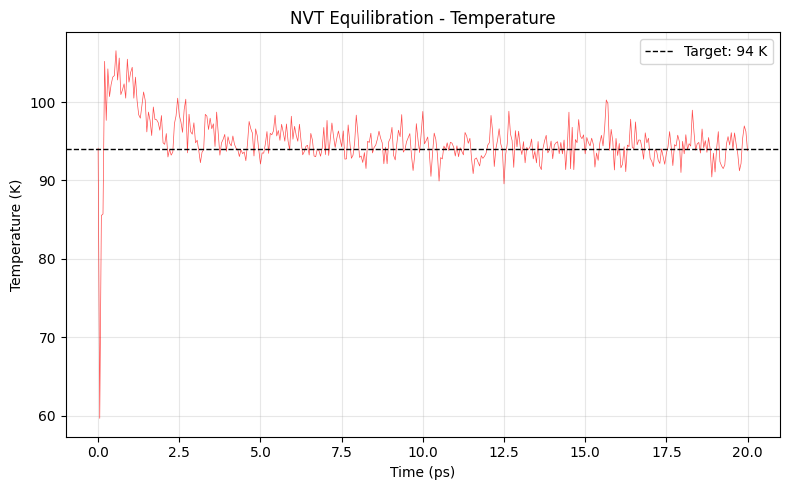

Average temperature (second half): 94.2 K


In [11]:
proc = subprocess.run(
    ["gmx", "energy", "-f", "nvt.edr", "-o", "nvt_temp.xvg"],
    input="Temperature\n\n", capture_output=True, text=True
)

if os.path.exists("nvt_temp.xvg"):
    time, temp = parse_xvg("nvt_temp.xvg")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time, temp, 'r-', linewidth=0.5, alpha=0.7)
    ax.axhline(y=94, color='k', linestyle='--', linewidth=1, label='Target: 94 K')
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Temperature (K)")
    ax.set_title("NVT Equilibration - Temperature")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("nvt_temperature.png", dpi=150)
    plt.show()
    print(f"Average temperature (second half): {np.mean(temp[len(temp)//2:]):.1f} K")

In [12]:
npt_mdp = """\
; NPT equilibration for NH3 solid at 94 K, 1.5 bar (OPLS-AA)
integrator  = md
dt          = 0.0005
nsteps      = 40000

nstxout     = 1000
nstvout     = 1000
nstenergy   = 100
nstlog      = 1000

cutoff-scheme = Verlet
nstlist       = 20
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

tcoupl        = v-rescale
tc-grps       = System
tau-t         = 0.1
ref-t         = 94

pcoupl        = Parrinello-Rahman
pcoupltype    = isotropic
tau-p         = 2.0
ref-p         = 1.5
compressibility = 4.5e-5

constraints   = none

gen-vel       = no
continuation  = yes
"""

with open("npt.mdp", "w") as f:
    f.write(npt_mdp)
print("Written npt.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "npt.mdp", "-c", "nvt.gro", "-t", "nvt.cpt",
     "-p", "nh3_sim.top", "-o", "npt.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print(result.stdout[-300:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("NPT grompp successful.")

result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "npt"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr[-300:])
else:
    print("\nNPT equilibration complete.")

Written npt.mdp
d whole trajectory

Using frame at t = 20 ps

Starting time for run is 0 ps
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 25x25x25, spacing 0.120 0.120 0.120

Estimate for the relative computational load of the PME mesh part: 0.24

This run will generate roughly 3 Mb of data

NPT grompp successful.


NPT equilibration complete.


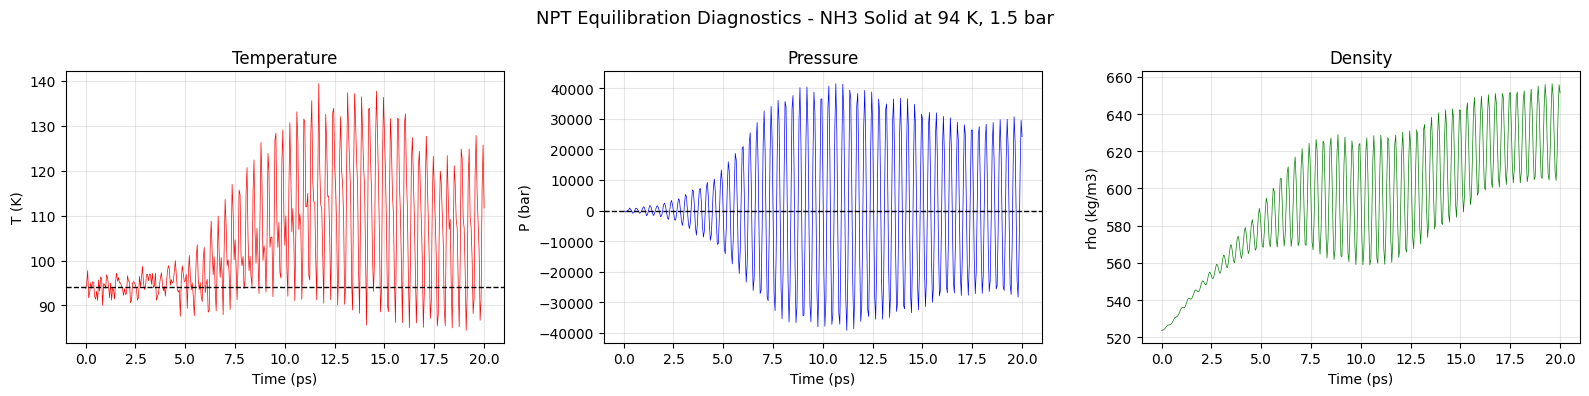

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

proc = subprocess.run(["gmx", "energy", "-f", "npt.edr", "-o", "npt_temp.xvg"],
                       input="Temperature\n\n", capture_output=True, text=True)
if os.path.exists("npt_temp.xvg"):
    t, temp = parse_xvg("npt_temp.xvg")
    axes[0].plot(t, temp, 'r-', lw=0.5)
    axes[0].axhline(94, color='k', ls='--', lw=1)
    axes[0].set_title("Temperature")
    axes[0].set_ylabel("T (K)")

proc = subprocess.run(["gmx", "energy", "-f", "npt.edr", "-o", "npt_press.xvg"],
                       input="Pressure\n\n", capture_output=True, text=True)
if os.path.exists("npt_press.xvg"):
    t, press = parse_xvg("npt_press.xvg")
    axes[1].plot(t, press, 'b-', lw=0.5)
    axes[1].axhline(1.5, color='k', ls='--', lw=1)
    axes[1].set_title("Pressure")
    axes[1].set_ylabel("P (bar)")

proc = subprocess.run(["gmx", "energy", "-f", "npt.edr", "-o", "npt_dens.xvg"],
                       input="Density\n\n", capture_output=True, text=True)
if os.path.exists("npt_dens.xvg"):
    t, dens = parse_xvg("npt_dens.xvg")
    axes[2].plot(t, dens, 'g-', lw=0.5)
    axes[2].set_title("Density")
    axes[2].set_ylabel("rho (kg/m3)")

for ax in axes:
    ax.set_xlabel("Time (ps)")
    ax.grid(True, alpha=0.3)

plt.suptitle("NPT Equilibration Diagnostics - NH3 Solid at 94 K, 1.5 bar", fontsize=13)
plt.tight_layout()
plt.savefig("npt_diagnostics.png", dpi=150)
plt.show()

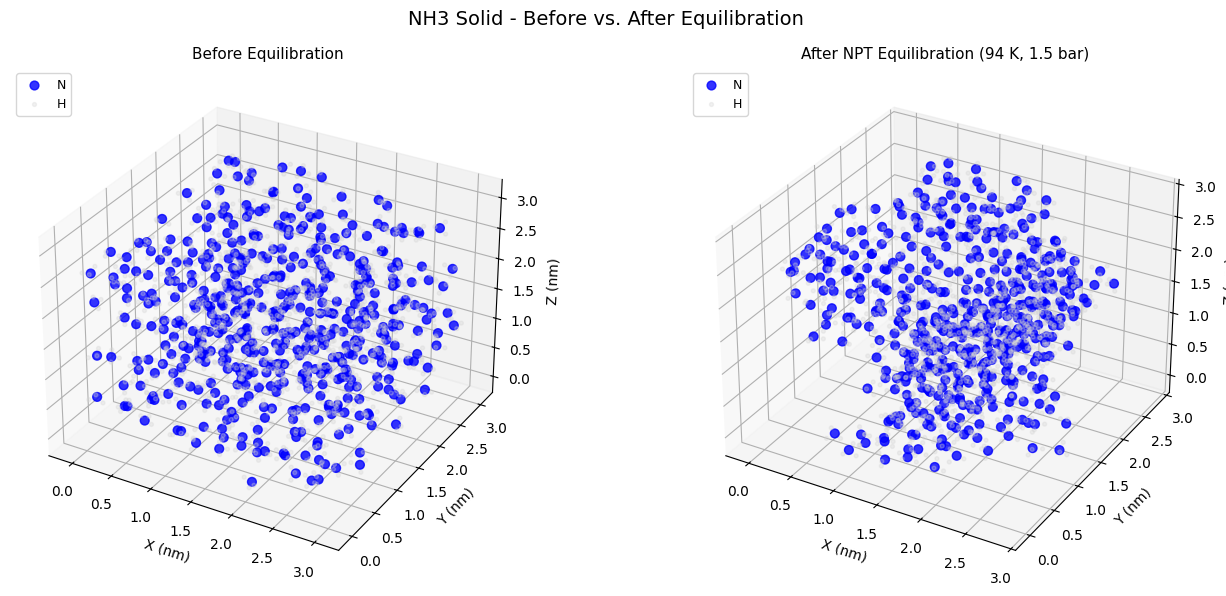

In [14]:
pos_before = parse_gro_positions_nh3("nh3_sim.gro")
pos_after = parse_gro_positions_nh3("npt.gro")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

for ax, pos, title in zip(axes, [pos_before, pos_after],
                            ["Before Equilibration", "After NPT Equilibration (94 K, 1.5 bar)"]):
    if "N" in pos:
        ax.scatter(pos["N"][:, 0], pos["N"][:, 1], pos["N"][:, 2],
                   c='blue', s=40, alpha=0.8, label='N')
    if "H" in pos:
        ax.scatter(pos["H"][:, 0], pos["H"][:, 1], pos["H"][:, 2],
                   c='lightgray', s=8, alpha=0.3, label='H')
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle("NH3 Solid - Before vs. After Equilibration", fontsize=14)
plt.tight_layout()
plt.savefig("structure_comparison.png", dpi=150)
plt.show()

In [15]:
prd_mdp = """\
; NVE Production for VDOS - NH3 solid (OPLS-AA)
integrator  = md
dt          = 0.0005
nsteps      = 40000

nstxout     = 0
nstvout     = 1
nstfout     = 0
nstenergy   = 100
nstlog      = 1000
nstxout-compressed = 1000

cutoff-scheme = Verlet
nstlist       = 20
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

tcoupl        = no
pcoupl        = no

constraints   = none

gen-vel       = no
continuation  = yes
"""

with open("prd.mdp", "w") as f:
    f.write(prd_mdp)
print("Written prd.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "prd.mdp", "-c", "npt.gro", "-t", "npt.cpt",
     "-p", "nh3_sim.top", "-o", "prd.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print(result.stdout[-300:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("Production grompp successful.")

Written prd.mdp
whole trajectory

Using frame at t = 20 ps

Starting time for run is 0 ps
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 24x24x24, spacing 0.116 0.116 0.116

Estimate for the relative computational load of the PME mesh part: 0.20

This run will generate roughly 917 Mb of data

Production grompp successful.


In [16]:
print("Starting NVE production run (20 ps, velocities every 0.5 fs)...")
print("This will take a while on a MacBook Air. Be patient.\n")

result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "prd"],
    capture_output=True, text=True
)

output = result.stdout + result.stderr
print(output[-1000:] if len(output) > 1000 else output)

if result.returncode == 0:
    print("\nProduction run complete.")
else:
    print("\nProduction run failed. Check the output above.")

for f in ["prd.trr", "prd.edr", "prd.xtc"]:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  {f}: {size_mb:.1f} MB")

Starting NVE production run (20 ps, velocities every 0.5 fs)...
This will take a while on a MacBook Air. Be patient.

       
step 38900, remaining wall clock time:     1 s          
step 39000, remaining wall clock time:     1 s          
step 39100, remaining wall clock time:     1 s          
step 39200, remaining wall clock time:     1 s          
step 39300, remaining wall clock time:     1 s          
step 39400, remaining wall clock time:     0 s          
step 39500, remaining wall clock time:     0 s          
step 39600, remaining wall clock time:     0 s          
step 39700, remaining wall clock time:     0 s          
step 39800, remaining wall clock time:     0 s          
step 39900, remaining wall clock time:     0 s          
Writing final coordinates.

step 40000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:      490.487       61.311      800.0
                 (ns/day)    (hour/ns)
Performance:       28.1

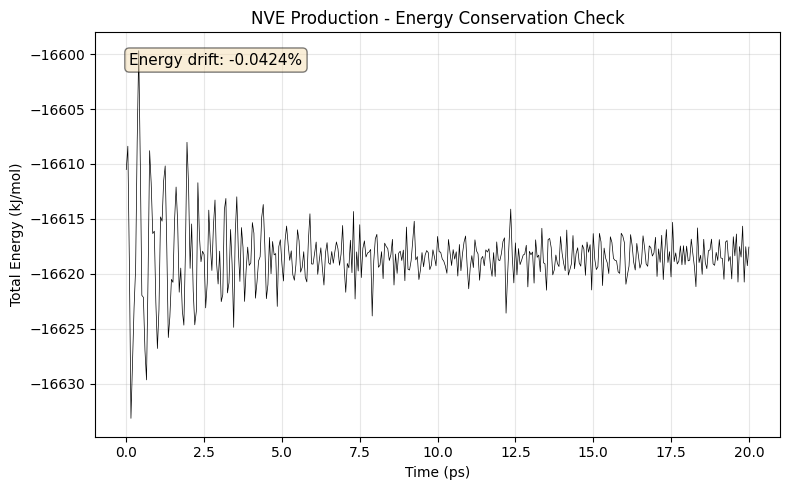

Energy drift over 20 ps: -0.0424%


In [17]:
proc = subprocess.run(
    ["gmx", "energy", "-f", "prd.edr", "-o", "prd_energy.xvg"],
    input="Total-Energy\n\n", capture_output=True, text=True
)

if os.path.exists("prd_energy.xvg"):
    t, etot = parse_xvg("prd_energy.xvg")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t, etot, 'k-', lw=0.5)
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Total Energy (kJ/mol)")
    ax.set_title("NVE Production - Energy Conservation Check")
    ax.grid(True, alpha=0.3)

    drift = (etot[-1] - etot[0]) / abs(etot[0]) * 100
    ax.text(0.05, 0.95, f"Energy drift: {drift:.4f}%", transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig("nve_energy_conservation.png", dpi=150)
    plt.show()
    print(f"Energy drift over 20 ps: {drift:.4f}%")

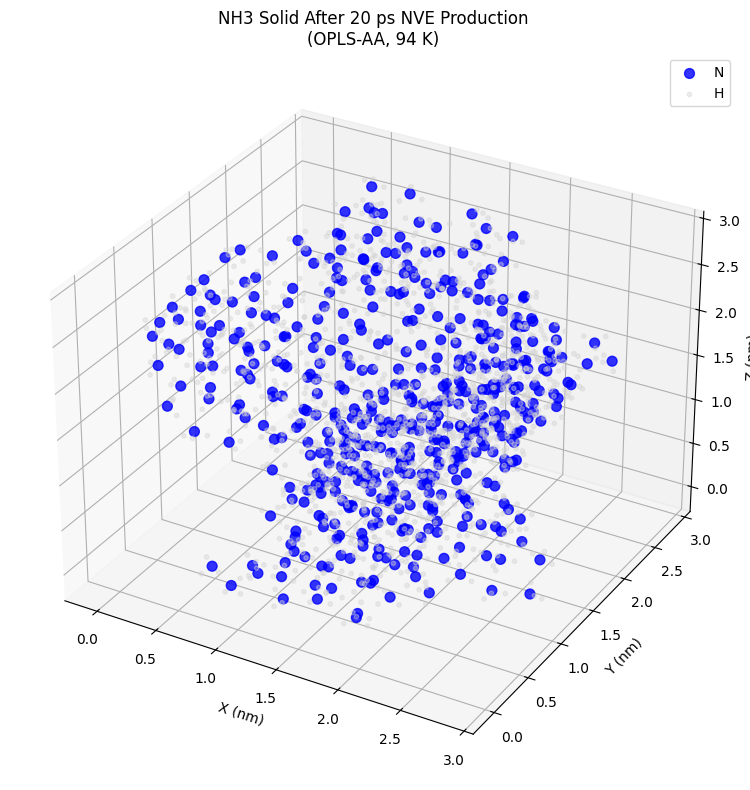

Post-production structure visualization saved.


In [18]:
pos_final = parse_gro_positions_nh3("prd.gro")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

if "N" in pos_final:
    ax.scatter(pos_final["N"][:, 0], pos_final["N"][:, 1], pos_final["N"][:, 2],
               c='blue', s=50, alpha=0.8, label='N')
if "H" in pos_final:
    ax.scatter(pos_final["H"][:, 0], pos_final["H"][:, 1], pos_final["H"][:, 2],
               c='lightgray', s=10, alpha=0.4, label='H')

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title('NH3 Solid After 20 ps NVE Production\n(OPLS-AA, 94 K)')
ax.legend()
plt.tight_layout()
plt.savefig("post_production_structure.png", dpi=150)
plt.show()
print("Post-production structure visualization saved.")

In [19]:
result = subprocess.run(
    ["gmx", "make_ndx", "-f", "prd.tpr", "-o", "index.ndx"],
    input="q\n",
    capture_output=True, text=True
)

print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("Index file generated: index.ndx")

System              :  2000 atoms
  1 Other               :  2000 atoms
  2 NH3                 :  2000 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index

> 

Index file generated: index.ndx


In [20]:
print("Computing velocity autocorrelation function and VDOS...")
print("This reads all 40,000 velocity frames and may take a minute.\n")

result = subprocess.run(
    ["gmx", "velacc",
     "-f", "prd.trr",
     "-s", "prd.tpr",
     "-n", "index.ndx",
     "-o", "vacf.xvg",
     "-os", "vdos.xvg",
     "-recip",
     "-normalize",
     "-acflen", "0",
     "-xvg", "none"],
    input="0\n",
    capture_output=True, text=True
)

print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("VDOS calculation complete.")
    for f in ["vacf.xvg", "vdos.xvg"]:
        if os.path.exists(f):
            print(f"  {f} exists.")

Computing velocity autocorrelation function and VDOS...
This reads all 40,000 velocity frames and may take a minute.

Selected 0: 'System'

VDOS calculation complete.
  vacf.xvg exists.
  vdos.xvg exists.


In [21]:
wavenumber, intensity = parse_xvg("vdos.xvg")
print(f"VDOS data: {len(wavenumber)} points")
print(f"Wavenumber range: {wavenumber[0]:.1f} to {wavenumber[-1]:.1f} cm-1")
print(f"Max intensity at: {wavenumber[np.argmax(intensity)]:.1f} cm-1")

VDOS data: 10000 points
Wavenumber range: 0.0 to 33353.1 cm-1
Max intensity at: 3432.4 cm-1


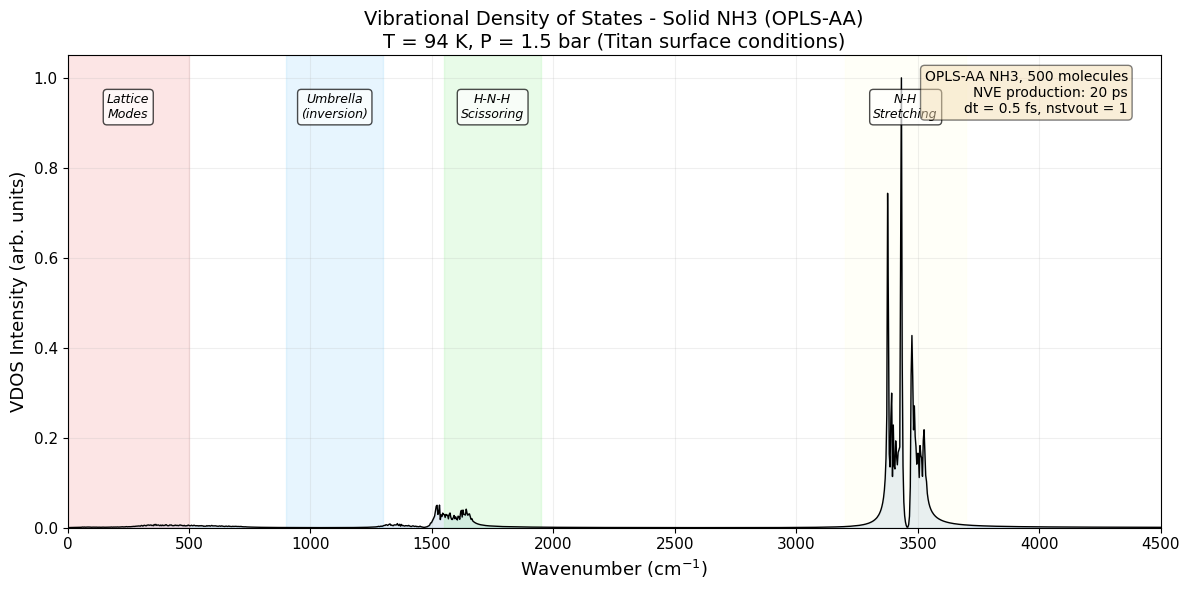

VDOS plot saved as nh3_solid_vdos.png and nh3_solid_vdos.pdf


In [22]:
wavenumber, intensity = parse_xvg("vdos.xvg")

mask = (wavenumber >= 0) & (wavenumber <= 4500)
wn = wavenumber[mask]
inten = intensity[mask]
inten = inten / np.max(inten)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wn, inten, 'k-', linewidth=1.0)
ax.fill_between(wn, inten, alpha=0.15, color='steelblue')

bands = [
    (0, 500, "Lattice\nModes", 'lightcoral'),
    (900, 1300, "Umbrella\n(inversion)", 'lightskyblue'),
    (1550, 1950, "H-N-H\nScissoring", 'lightgreen'),
    (3200, 3700, "N-H\nStretching", 'lightyellow'),
]

for lo, hi, label, color in bands:
    ax.axvspan(lo, hi, alpha=0.2, color=color)
    mid = (lo + hi) / 2
    ax.text(mid, 0.92, label,
            ha='center', va='top', fontsize=9, fontstyle='italic',
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=13)
ax.set_ylabel("VDOS Intensity (arb. units)", fontsize=13)
ax.set_title("Vibrational Density of States - Solid NH3 (OPLS-AA)\n"
             "T = 94 K, P = 1.5 bar (Titan surface conditions)", fontsize=14)
ax.set_xlim(0, 4500)
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.2)

textstr = (f"OPLS-AA NH3, {n_mol} molecules\n"
           f"NVE production: 20 ps\n"
           f"dt = 0.5 fs, nstvout = 1")
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig("nh3_solid_vdos.png", dpi=300, bbox_inches='tight')
plt.savefig("nh3_solid_vdos.pdf", bbox_inches='tight')
plt.show()

print("VDOS plot saved as nh3_solid_vdos.png and nh3_solid_vdos.pdf")

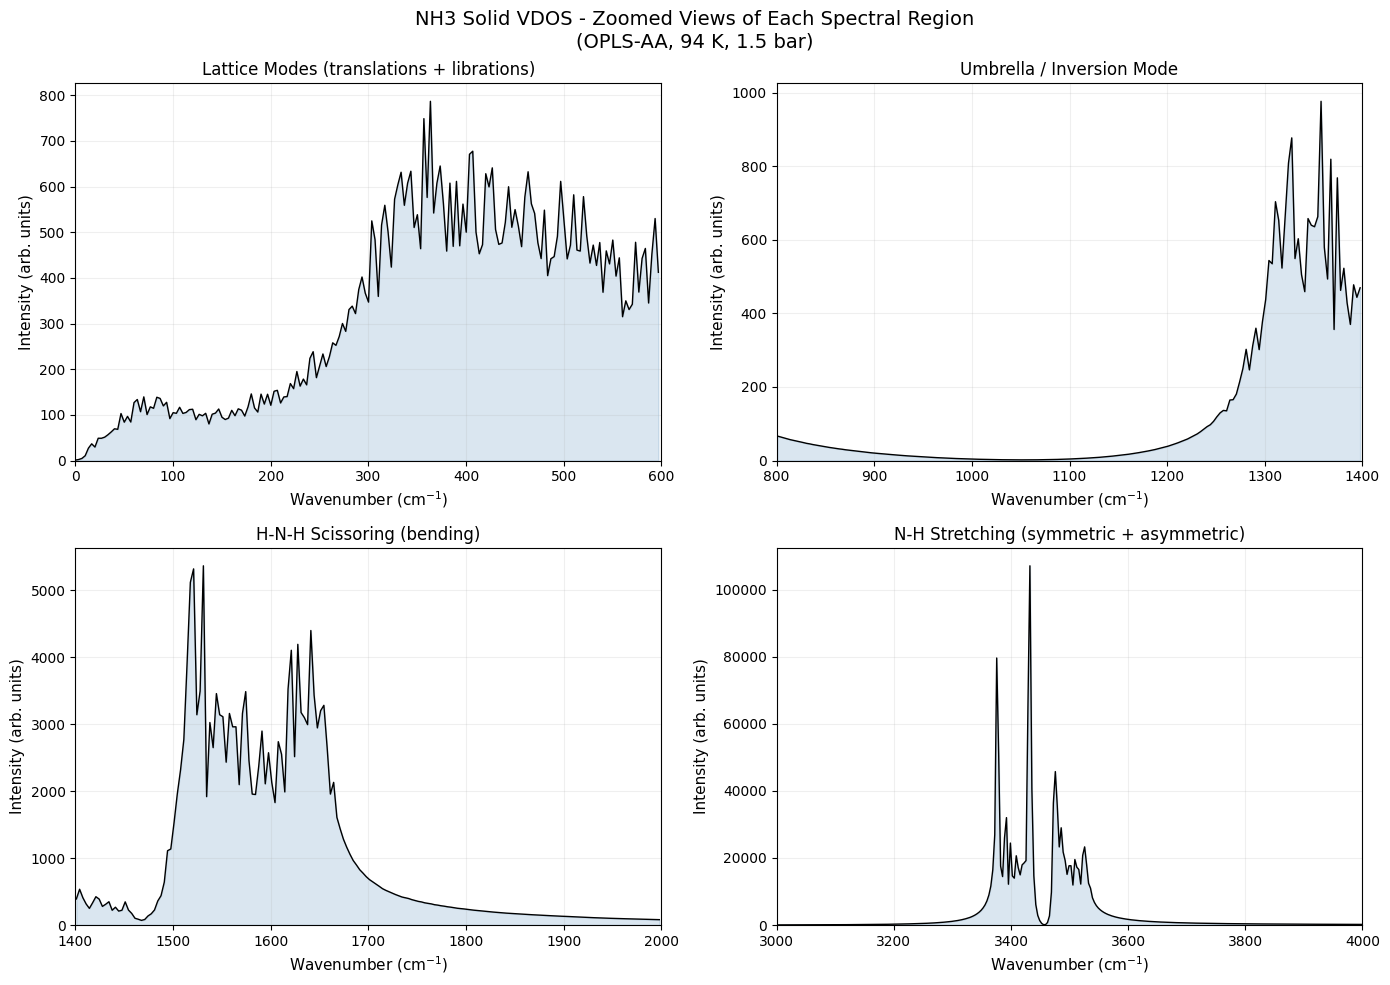

Zoomed VDOS saved: nh3_vdos_zoomed.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

wavenumber, intensity = parse_xvg("vdos.xvg")

regions = [
    (axes[0, 0], 0, 600, "Lattice Modes (translations + librations)"),
    (axes[0, 1], 800, 1400, "Umbrella / Inversion Mode"),
    (axes[1, 0], 1400, 2000, "H-N-H Scissoring (bending)"),
    (axes[1, 1], 3000, 4000, "N-H Stretching (symmetric + asymmetric)"),
]

for ax, lo, hi, title in regions:
    mask = (wavenumber >= lo) & (wavenumber <= hi)
    wn = wavenumber[mask]
    inten = intensity[mask]

    ax.plot(wn, inten, 'k-', linewidth=1.0)
    ax.fill_between(wn, inten, alpha=0.2, color='steelblue')
    ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=11)
    ax.set_ylabel("Intensity (arb. units)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(lo, hi)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.2)

plt.suptitle("NH3 Solid VDOS - Zoomed Views of Each Spectral Region\n(OPLS-AA, 94 K, 1.5 bar)",
             fontsize=14)
plt.tight_layout()
plt.savefig("nh3_vdos_zoomed.png", dpi=200, bbox_inches='tight')
plt.show()
print("Zoomed VDOS saved: nh3_vdos_zoomed.png")

In [24]:
# First, extract a short piece of the.trr with coordinates
# We'll use trjconv to dump every 10th frame from the first 1 ps (2000 frames -> 200 frames)
# and only for a subset of molecules near the center

import mdtraj as md

# Load just the first 500 frames (0.25 ps) from the xtc for the full system view
# Then we'll use the.trr for a detailed short animation
print("Loading compressed trajectory for molecule selection...")
traj_full = md.load("prd.xtc", top="prd.gro")
print(f"Compressed trajectory: {traj_full.n_frames} frames, {traj_full.n_atoms} atoms")

# Find molecules near the center of the box
topology = traj_full.topology
positions_0 = traj_full.xyz[0]
box_center = traj_full.unitcell_lengths[0] / 2.0

# Get nitrogen indices and find those near center
n_indices = [a.index for a in topology.atoms if a.name == "N"]
h_indices = [a.index for a in topology.atoms if a.name in ("H1", "H2", "H3")]

# Find nitrogens within 0.6 nm of box center
nearby_n = []
for ni in n_indices:
    delta = positions_0[ni] - box_center
    box = traj_full.unitcell_lengths[0]
    delta -= box * np.round(delta / box)
    if np.linalg.norm(delta) < 0.6:
        nearby_n.append(ni)

# Get the hydrogens bonded to those nitrogens
# Each N is followed by H1, H2, H3 in the.gro (indices N, N+1, N+2, N+3)
nearby_atoms = []
for ni in nearby_n:
    nearby_atoms.extend([ni, ni+1, ni+2, ni+3])

print(f"Selected {len(nearby_n)} NH3 molecules ({len(nearby_atoms)} atoms) near box center")

Loading compressed trajectory for molecule selection...
Compressed trajectory: 41 frames, 2000 atoms
Selected 21 NH3 molecules (84 atoms) near box center


In [26]:
# Load a subset of the.trr (first 500 frames = 0.25 ps)
# This captures several periods of the N-H stretch (~9.5 fs period -> ~26 periods in 0.25 ps)
print("Loading first 500 frames from.trr (this may take a moment)...")

# mdtraj can slice on load
traj_trr = md.load("prd.trr", top="prd.gro")
print(f"Full.trr: {traj_trr.n_frames} frames")

# Take every 5th frame from the first 1000 frames -> 200 frames covering 0.5 ps
# This gives ~5 frames per N-H stretch period, enough to see the motion
step = 5
end_frame = 1000
traj_anim = traj_trr[0:end_frame:step]
print(f"Animation trajectory: {traj_anim.n_frames} frames, dt between frames = {step * 0.5:.1f} fs")
print(f"Time span: {traj_anim.n_frames * step * 0.0005:.3f} ps")

Loading first 500 frames from.trr (this may take a moment)...
Full.trr: 40001 frames
Animation trajectory: 200 frames, dt between frames = 2.5 fs
Time span: 0.500 ps


In [27]:
# Build N-H bond pairs for the selected molecules
bonds_anim = []
for ni in nearby_n:
    bonds_anim.append((ni, ni+1))  # N-H1
    bonds_anim.append((ni, ni+2))  # N-H2
    bonds_anim.append((ni, ni+3))  # N-H3

# Also find N...N pairs for intermolecular hydrogen bonds (within 0.38 nm)
def get_hbonds(positions, nearby_n, box):
    """Find N...N pairs within hydrogen bonding distance."""
    hbonds = []
    for i, ni1 in enumerate(nearby_n):
        for j, ni2 in enumerate(nearby_n):
            if ni1 >= ni2:
                continue
            delta = positions[ni1] - positions[ni2]
            delta -= box * np.round(delta / box)
            dist = np.linalg.norm(delta)
            if 0.28 < dist < 0.38:
                hbonds.append((ni1, ni2))
    return hbonds

print(f"Covalent N-H bonds to draw: {len(bonds_anim)}")
hbonds_0 = get_hbonds(traj_anim.xyz[0], nearby_n, traj_anim.unitcell_lengths[0])
print(f"Hydrogen bonds (N...N) in first frame: {len(hbonds_0)}")

Covalent N-H bonds to draw: 63
Hydrogen bonds (N...N) in first frame: 0


In [28]:
from PIL import Image
import io

print(f"Rendering {traj_anim.n_frames} frames...")

frames = []
for frame_idx in range(traj_anim.n_frames):
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')

    pos_frame = traj_anim.xyz[frame_idx]
    box_frame = traj_anim.unitcell_lengths[frame_idx]

    # Get positions of nearby atoms
    n_pos_f = pos_frame[nearby_n]
    h_pos_f = pos_frame[[ni+1 for ni in nearby_n] +
                         [ni+2 for ni in nearby_n] +
                         [ni+3 for ni in nearby_n]]

    # Draw nitrogen atoms (blue, large)
    ax.scatter(n_pos_f[:, 0], n_pos_f[:, 1], n_pos_f[:, 2],
               c='blue', s=300, alpha=0.95, depthshade=True, edgecolors='darkblue')

    # Draw hydrogen atoms (white with gray edge)
    ax.scatter(h_pos_f[:, 0], h_pos_f[:, 1], h_pos_f[:, 2],
               c='white', s=120, alpha=0.95, depthshade=True, edgecolors='gray')

    # Draw covalent bonds (thick gray)
    for ni, hi in bonds_anim:
        p1 = pos_frame[ni]
        p2 = pos_frame[hi]
        delta = p1 - p2
        delta -= box_frame * np.round(delta / box_frame)
        if np.linalg.norm(delta) < 0.15:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                    'dimgray', linewidth=3, alpha=0.8)

    # Draw hydrogen bonds (dashed gold)
    hbonds_f = get_hbonds(pos_frame, nearby_n, box_frame)
    for ni1, ni2 in hbonds_f:
        p1 = pos_frame[ni1]
        p2 = pos_frame[ni2]
        delta = p1 - p2
        delta -= box_frame * np.round(delta / box_frame)
        p2_img = p1 - delta
        ax.plot([p1[0], p2_img[0]], [p1[1], p2_img[1]], [p1[2], p2_img[2]],
                'gold', linewidth=1.5, alpha=0.4, linestyle='--')

    # Fix view limits to prevent jitter
    all_nearby_pos = pos_frame[nearby_atoms]
    mid = np.mean(all_nearby_pos, axis=0)
    span = 0.7
    ax.set_xlim(mid[0] - span, mid[0] + span)
    ax.set_ylim(mid[1] - span, mid[1] + span)
    ax.set_zlim(mid[2] - span, mid[2] + span)

    time_fs = frame_idx * step * 0.5
    ax.set_title(f'NH3 Molecular Vibrations (OPLS-AA, 94 K)\nt = {time_fs:.1f} fs', fontsize=12)
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)

    if (frame_idx + 1) % 50 == 0:
        print(f"  Rendered frame {frame_idx + 1}/{traj_anim.n_frames}")

print(f"All {len(frames)} frames rendered.")

# Save as GIF
frames[0].save(
    "nh3_vibrations.gif",
    save_all=True,
    append_images=frames[1:],
    duration=80,
    loop=0
)

file_size = os.path.getsize("nh3_vibrations.gif") / (1024**2)
print(f"Animation saved: nh3_vibrations.gif ({file_size:.1f} MB)")

Rendering 200 frames...
  Rendered frame 50/200
  Rendered frame 100/200
  Rendered frame 150/200
  Rendered frame 200/200
All 200 frames rendered.
Animation saved: nh3_vibrations.gif (0.8 MB)
